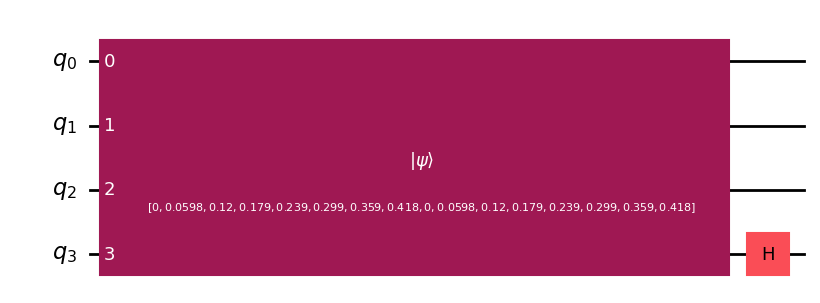

In [2]:
# importing necessary packages
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

x = np.arange(0,8,1) # create numpy array with 8 inputs that step by 1 
y = x #y is also an array identically equal to x 

N = len(x) #N is length of x (8)             
nqubits = math.ceil(np.log2(N))    # compute how many qubits needed to encode either x or y since N = 8, log2(8)= 3 so nqubits=3
                                   # math.ceil rounds to next integer if needed
xnorm = np.linalg.norm(x)          # normalise vectors x and y
ynorm = np.linalg.norm(y)
x = x/xnorm  # divide each element by its norm making it a unit vector (length 1)
y = y/ynorm

circ = QuantumCircuit(nqubits+1)   # create circuit with nqubits, +1 is used as an ancilla or control qubit
vec = np.concatenate((x,y))/np.sqrt(2)    # concatenate x and y as above, then divide by root 2 to renormalisation

circ.initialize(vec, range(nqubits+1)) # initialize qc to the vector 'vec' across all qubits
circ.h(nqubits)                    # apply hadamard to bottom qubit


circ.draw('mpl')                        # draw the circuit

In [13]:
import numpy as np
import math
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

def inner_prod(vec1, vec2):
    if len(vec1) != len(vec2):
        raise ValueError('Lengths of states are not equal')

    N = len(vec1)
    nqubits = math.ceil(np.log2(N))

    # Combine and normalize the vector
    vec = np.concatenate((vec1, vec2)) / np.sqrt(2)

    # Create the circuit and initialize the combined state
    circ = QuantumCircuit(nqubits + 1)
    circ.initialize(vec, range(nqubits + 1))
    circ.h(nqubits)

    # Simulate the circuit to get the statevector
    state = Statevector.from_instruction(circ)
    real_amps = np.real(state.data)

    # Sum probabilities over first half of the basis states
    m_sum = sum(real_amps[l]**2 for l in range(N))

    return 2 * m_sum - 1

# Test vectors
x = np.arange(0, 8, 1)
y = x

x = x / np.linalg.norm(x)
y = y / np.linalg.norm(y)

print("x: ", x)
print("\ny: ", y)
print("\nThe inner product of x and y equals: ", inner_prod(x, y))


x:  [0.         0.08451543 0.16903085 0.25354628 0.3380617  0.42257713
 0.50709255 0.59160798]

y:  [0.         0.08451543 0.16903085 0.25354628 0.3380617  0.42257713
 0.50709255 0.59160798]

The inner product of x and y equals:  0.9999999999999991


In [14]:
#Implements the entire cost function by feeding the ansatz to the quantum circuit which computes inner products

def calculate_cost_function(parameters):

    a, b = parameters
    
    ansatz = a*x + b                        # compute ansatz
    ansatzNorm = np.linalg.norm(ansatz)     # normalise ansatz
    ansatz = ansatz/ansatzNorm
    
    y_ansatz = ansatzNorm/ynorm * inner_prod(y,ansatz)     # use quantum circuit to test ansatz
                                                           # note the normalisation factors
    return (1-y_ansatz)**2

x = np.arange(0,8,1)
y = x

N = len(x)
nqubits = math.ceil(np.log2(N))
ynorm = np.linalg.norm(y)
y = y/ynorm

a = 1.0
b = 1.0
print("Cost function for a =", a, "and b =", b, "equals:", calculate_cost_function([a,b]))

Cost function for a = 1.0 and b = 1.0 equals: 0.039999999999999536


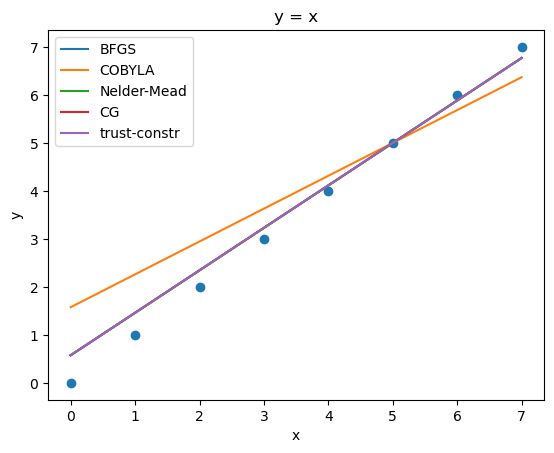

In [15]:
#first set up the data sets x and y

x = np.arange(0,8,1)
y = x   # + [random.uniform(-1,1) for p in range(8)]    # can add noise here
N = len(x)
nqubits = math.ceil(np.log2(N))
       
ynorm = np.linalg.norm(y)      # normalise the y data set
y = y/ynorm

x0 = [0.5,0.5]                 # initial guess for a and b

#now use different classical optimisers to see which one works best

out = minimize(calculate_cost_function, x0=x0, method="BFGS", options={'maxiter':200}, tol=1e-6)
out1 = minimize(calculate_cost_function, x0=x0, method="COBYLA", options={'maxiter':200}, tol=1e-6)
out2 = minimize(calculate_cost_function, x0=x0, method="Nelder-Mead", options={'maxiter':200}, tol=1e-6)
out3 = minimize(calculate_cost_function, x0=x0, method="CG", options={'maxiter':200}, tol=1e-6)
out4 = minimize(calculate_cost_function, x0=x0, method="trust-constr", options={'maxiter':200}, tol=1e-6)

out_a1 = out1['x'][0]
out_b1 = out1['x'][1]

out_a = out['x'][0]
out_b = out['x'][1]

out_a2 = out2['x'][0]
out_b2 = out2['x'][1]

out_a3 = out3['x'][0]
out_b3 = out3['x'][1]

out_a4 = out4['x'][0]
out_b4 = out4['x'][1]

plt.scatter(x,y*ynorm)
xfit = np.linspace(min(x), max(x), 100)
plt.plot(xfit, out_a*xfit+out_b, label='BFGS')
plt.plot(xfit, out_a1*xfit+out_b1, label='COBYLA')
plt.plot(xfit, out_a2*xfit+out_b2, label='Nelder-Mead')
plt.plot(xfit, out_a3*xfit+out_b3, label='CG')
plt.plot(xfit, out_a4*xfit+out_b4, label='trust-constr')
plt.legend()
plt.title("y = x")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

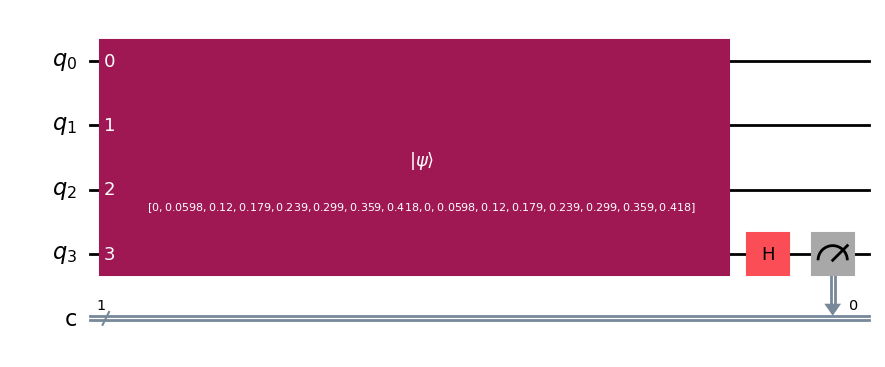

In [26]:
x = np.arange(0,8,1)    # define some vectors x and y
y = x

N = len(x)              
nqubits = math.ceil(np.log2(N))    # compute how many qubits needed to encode either x or y

xnorm = np.linalg.norm(x)          # normalise vectors x and y
ynorm = np.linalg.norm(y)
x = x/xnorm
y = y/ynorm

circ = QuantumCircuit(nqubits+1,1)   # create circuit
vec = np.concatenate((x,y))/np.sqrt(2)    # concatenate x and y as above, with renormalisation

circ.initialize(vec, range(nqubits+1))
circ.h(nqubits)                    # apply hadamard to bottom qubit
circ.measure(nqubits,0)            # measure bottom qubit in computational basis

circ.draw('mpl')                        # draw the circuit

In [ ]:
import numpy as np
import math
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

def inner_prod(vec1, vec2): #func to estimate the interproduct betweeen the 2
    if len(vec1) != len(vec2): # if loop to give error string if not equal 
        raise ValueError('Lengths of states are not equal')

    N = len(vec1) # N is the length of vec 1 
    nqubits = math.ceil(np.log2(N)) #compute the num of qubits needed to encode

    # Combine vec1 and vec2 into a superposition state then renormalize again
    vec = np.concatenate((vec1, vec2)) / np.sqrt(2)

    # Create quantum circuit with ancilla
    circ = QuantumCircuit(nqubits + 1)
    circ.initialize(vec, range(nqubits + 1)) # initialize again 
    circ.h(nqubits)  # Hadamard on ancilla qubit

    # Get the final statevector
    state = Statevector.from_instruction(circ) # simulate the full statevector resulting from circ
    amps = state.data # take the data from state vector and initialize as amps


    m_sum = 0 # initialize variable m_sum
    for i, amp in enumerate(amps): # for loop looping over all amps 
        if (i >> nqubits) & 1 == 0:  # checks if the ancilla is 0 
            m_sum += np.abs(amp)**2 # if so then add the square of magnitude of amp to m_sum 

    # Return the estimated inner product
    return 2 * m_sum - 1

# Example vectors
x = np.arange(0, 8, 1) # creates array from 0 with 8 entries stepping by 1 
y = x # set y as the same array as x 

x = x / np.linalg.norm(x) # normalize by dividing its norm (unit vector)
y = y / np.linalg.norm(y) # same as above 

print("x: ", x) # print value of x 
print("\ny: ", y) #print value of y 
print("\nThe inner product of x and y equals: ", inner_prod(x, y)) #compute and print value of inner product


x:  [0.         0.08451543 0.16903085 0.25354628 0.3380617  0.42257713
 0.50709255 0.59160798]

y:  [0.         0.08451543 0.16903085 0.25354628 0.3380617  0.42257713
 0.50709255 0.59160798]

The inner product of x and y equals:  0.9999999999999991


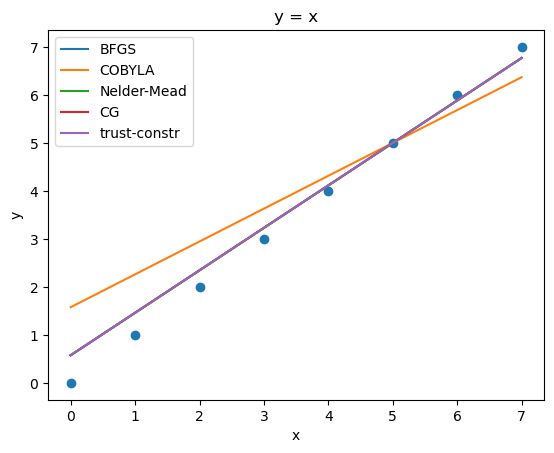

In [ ]:
#first set up the data sets x and y

x = np.arange(0,8,1) # another array same deal 
y = x   
N = len(x) # N =
nqubits = math.ceil(np.log2(N)) # calculate N= 8 so nqubits = 3

ynorm = np.linalg.norm(y)    # calculate norm
y = y/ynorm # normalize (unit vector)

x0 = [0.5,0.5]       # initial guess for a and b

#now use different classical optimisers to see which one works best

out = minimize(calculate_cost_function, x0=x0, method="BFGS", options={'maxiter':200}, tol=1e-6)
out1 = minimize(calculate_cost_function, x0=x0, method="COBYLA", options={'maxiter':200}, tol=1e-6)
out2 = minimize(calculate_cost_function, x0=x0, method="Nelder-Mead", options={'maxiter':200}, tol=1e-6)
out3 = minimize(calculate_cost_function, x0=x0, method="CG", options={'maxiter':200}, tol=1e-6)
out4 = minimize(calculate_cost_function, x0=x0, method="trust-constr", options={'maxiter':200}, tol=1e-6)

out_a1 = out1['x'][0] #output for COBYLA
out_b1 = out1['x'][1]

out_a = out['x'][0] #output for BFGS
out_b = out['x'][1]

out_a2 = out2['x'][0] # output for Nelder-Mead
out_b2 = out2['x'][1]

out_a3 = out3['x'][0] #output for CG
out_b3 = out3['x'][1]

out_a4 = out4['x'][0] #output for trust-constr
out_b4 = out4['x'][1]

plt.scatter(x,y*ynorm) #scatter plot 
xfit = np.linspace(min(x), max(x), 100) # create a smooth line for x values 
plt.plot(xfit, out_a*xfit+out_b, label='BFGS') # fitted line fro each method
plt.plot(xfit, out_a1*xfit+out_b1, label='COBYLA') # fitted line fro each method
plt.plot(xfit, out_a2*xfit+out_b2, label='Nelder-Mead') # fitted line fro each method
plt.plot(xfit, out_a3*xfit+out_b3, label='CG') # fitted line fro each method
plt.plot(xfit, out_a4*xfit+out_b4, label='trust-constr') # fitted line fro each method
plt.legend() # created legend 
plt.title("y = x") # title
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [ ]:
# calculate cost func using above parameters 
def calculate_cost_function_n(parameters):
    
    ansatz = parameters[0]                   # compute ansatz

    for i in range(1,len(parameters)): #loop with indicie i

        ansatz += parameters[i] * x**i # add ai * x^i term 
        
    ansatzNorm = np.linalg.norm(ansatz)      # normalise ansatz
    ansatz = ansatz/ansatzNorm #normalize ansatz vector
    y_ansatz = ansatzNorm/ynorm * inner_prod(y,ansatz)     # use quantum circuit to test ansatz
                                                           # scales result back to the original data 

    return (1-y_ansatz)**2 # calculate and return the cost func 

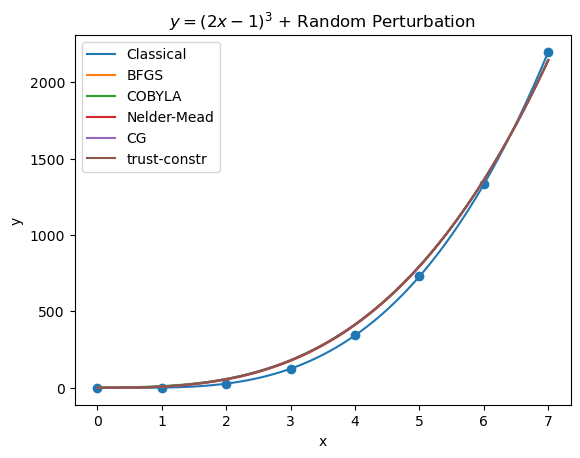

In [ ]:
#first set up the data sets x and y

x = np.arange(0,8,1)
y = (2*x-1)**3 + [random.uniform(-1,1) for p in range(8)] # creates a cubic function with added random noise in the certain range
N = len(x)
nqubits = math.ceil(np.log2(N))
       
ynorm = np.linalg.norm(y)       # calc the norm of y vector 
y = y/ynorm #normalize 

order = 3 # define polynomial order 

x0 = [random.uniform(0,2) for p in range(order+1)]    #random initial guess for a and b

#now use different classical optimisers to see which one works best

out = minimize(calculate_cost_function_n, x0=x0, method="BFGS", options={'maxiter':200}, tol=1e-6)
out1 = minimize(calculate_cost_function_n, x0=x0, method="COBYLA", options={'maxiter':200}, tol=1e-6)
out2 = minimize(calculate_cost_function_n, x0=x0, method="Nelder-Mead", options={'maxiter':200}, tol=1e-6)
out3 = minimize(calculate_cost_function_n, x0=x0, method="CG", options={'maxiter':200}, tol=1e-6)
out4 = minimize(calculate_cost_function_n, x0=x0, method="trust-constr", options={'maxiter':200}, tol=1e-6)

class_fit = np.polyfit(x,y*ynorm,order) # fit polynomial to original data 
class_fit = class_fit[::-1] # this reverses the order 

xfit = np.linspace(min(x), max(x), 100) # wants data point from 0 to 7 since N = 8

def return_fits(xfit): # evaluate all fitted polynomials at x values 

    # initialize arrays 
    c_fit = np.zeros(100) # classical polynomial fit 
    q_fit = np.zeros(100) # BFGS
    q_fit1 = np.zeros(100) # COBYLA
    q_fit2 = np.zeros(100) # Nelder-Mead
    q_fit3 = np.zeros(100) # CG
    q_fit4 = np.zeros(100) # Trust-constr


    for i in range(order+1): # for loop with i indicies over order = 3
        c_fit += xfit**i*class_fit[i] 
        q_fit += xfit**i*out['x'][i]
        q_fit1 += xfit**i*out1['x'][i]
        q_fit2 += xfit**i*out2['x'][i]
        q_fit3 += xfit**i*out3['x'][i]
        q_fit4 += xfit**i*out4['x'][i]
        

    return c_fit, q_fit, q_fit1, q_fit2, q_fit3, q_fit4 # return arrays 

c_fit, q_fit, q_fit1, q_fit2, q_fit3, q_fit4 = return_fits(xfit) # compute all arrays 

plt.scatter(x,y*ynorm) # plot original noisy data (not normalized )
xfit = np.linspace(min(x), max(x), 100) # same as last plot 
plt.plot(xfit, c_fit, label='Classical')
plt.plot(xfit, q_fit, label='BFGS')
plt.plot(xfit, q_fit1, label='COBYLA')
plt.plot(xfit, q_fit2, label='Nelder-Mead')
plt.plot(xfit, q_fit3, label='CG')
plt.plot(xfit, q_fit4, label='trust-constr')
plt.legend()
plt.title("$y = (2x-1)^3$ + Random Perturbation")
plt.xlabel("x")
plt.ylabel("y")
plt.show()